# Lab 1: Introduction to EDA and ETL in Data Engineering
A data team typically contains several different roles:
- *data engineer*: maintain the infrastructure and workflows that allow data to move from raw sources into reliable, usable forms
- *data analysts*: build dashboards and business reports
- *data scientists*: explore patterns and develop predictive models
- *machine learning engineers*: deploy and maintain ML systems
- *product/ business teams*: make decisions based on data

In data engineering, raw data often arrives in messy or inconvenient formats. Before it can be used for analytics, machine learning, or reporting, we need to **inspect it, clean it, transform it, and store it** in a more usable form.

In this lab, you will be introduced to 2 key tasks in data engineering:
- **Exploratory Data Analysis (EDA)**: understanding the structure, quality, and patterns of a dataset
- **Extract, Transform, Load (ETL)**: building a simple pipeline to ingest, clean, and store data for downstream use

We will use a flight dataset as the main example and connect EDA with ETL as two parts of the same workflow.

## Exploratory Data Analysis (EDA)
EDA helps data engineers to understand
- what the data looks like
- whether the data is complete and trustworthy
- whether the schema is consistent
- whether downstream users can actually use it

A typical EDA process is involved with exploring
- size and shape
- column meanings and types
- missing values
- unusual values or outliers
- distributions
- relationships between variables

## Extract, Transform, Load (ETL)
ETL stands for:

- **Extract**: get data from one or more sources
- **Transform**: clean, standardize, enrich, and validate it
- **Load**: store it into a target system for later use

Typical workflow:
1. Extract raw data
2. Inspect structure and sample rows
3. Compute summary statistics
4. Visualize key variables
5. Identify data quality issues
6. Transform data
7. Save cleaned data for downstream use

## Exercise: Carrier On-Time Performance Dataset
### 1. Setup and data loading
Load the load with 29 columns out of 109:

[
    # 29 columns out of 109
    "Year", "Month", "DayofMonth", "DayOfWeek", "DepTime", "CRSDepTime",
    "ArrTime", "CRSArrTime", "Reporting_Airline","Flight_Number_Reporting_Airline",
    "Tail_Number", "ActualElapsedTime", "CRSElapsedTime", "AirTime", "ArrDelay", "DepDelay", "Origin", "Dest",
    "Distance", "TaxiIn", "TaxiOut", "Cancelled",
    "CancellationCode", "Diverted", "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay",
    "LateAircraftDelay"
]

And check the shape of the loaded data

In [91]:
import pandas as pd
import numpy as np

## Read data using 29 columns
use_cols = [
    # 29 columns out of 109
    "Year", "Month", "DayofMonth", "DayOfWeek", "DepTime", "CRSDepTime",
    "ArrTime", "CRSArrTime", "Reporting_Airline","Flight_Number_Reporting_Airline",
    "Tail_Number", "ActualElapsedTime", "CRSElapsedTime", "AirTime", "ArrDelay", "DepDelay", "Origin", "Dest",
    "Distance", "TaxiIn", "TaxiOut", "Cancelled",
    "CancellationCode", "Diverted", "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay",
    "LateAircraftDelay"
]

DATA_DIR = ''

## TO DO: read_csv()
airline_data = pd.read_csv("airline_2019.csv",usecols=use_cols)


## Check the shape of the loaded data
airline_data.shape

(76616, 29)

#### 1.1 Rename a few columns:
- "Reporting_Airline" -->  "UniqueCarrier"
- "Flight_Number_Reporting_Airline":"FlightNum"
- "Tail_Number":"TailNum"

A useful method here: `df.rename()` method: Original_Name:NewName
```python
df.rename(
    columns={
        
    },
    inplace=True
)
```

Column name convention:
 - **Snake Case Convention**: use underscores (_) to separate words
 - **Camel Case/ Pascal Case**: capitalize the first letter of each word

#### 1.2 Random sample 20k observations for further analysis

In [92]:
## 1.1 Rename a few columns
airline_data.rename(
    columns={
        "Reporting_Airline":"UniqueCarrier",
        "Flight_Number_Reporting_Airline":"FlightNum",
        "Tail_Number":"TailNum"
    },
    inplace=True
)

## 1.2 Random sampling for further analysis
airline_samp = airline_data.sample(n=2000, random_state=42)

### 2. Basic EDA

In [93]:
## Print first 5 rows to check how the data looks like
airline_samp.head()

,Year,Month,DayofMonth,DayOfWeek,UniqueCarrier,TailNum,FlightNum,Origin,Dest,CRSDepTime,...,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
66952,2019,5,9,4,DL,N993AT,2182,BNA,DTW,1859,...,0.0,96.0,82.0,67.0,456.0,NaN,NaN,NaN,NaN,NaN
40788,2019,4,13,6,UA,N63890,2152,IAH,SEA,1950,...,0.0,289.0,293.0,243.0,1874.0,14.0,0.0,4.0,0.0,3.0
58392,2019,12,18,3,WN,N8655D,2233,SEA,OAK,1705,...,0.0,120.0,114.0,95.0,672.0,9.0,0.0,0.0,0.0,13.0
42540,2019,7,5,5,AA,N402AN,601,ORD,PHX,1335,...,0.0,222.0,274.0,193.0,1440.0,9.0,0.0,52.0,0.0,0.0
29690,2019,10,4,5,DL,N395DZ,1984,AUS,ATL,600,...,0.0,133.0,131.0,109.0,813.0,NaN,NaN,NaN,NaN,NaN


In [94]:
## Get descriptive statistics and missing value percentage for each column
def get_info(pd_frame):
    # generate descriptive statistics (like count, mean, std, min, etc.) for numeric columns
    res = pd_frame.describe().transpose()
    # calculate the missing percentage for each variable
    res['missing_percent'] = [(pd_frame.shape[0] - res.loc[ind, 'count'])/pd_frame.shape[0] for ind in res.index]
    #
    res['unique_val'] = [len(pd_frame.loc[:,ind].value_counts()) for ind in res.index]
    res['var_type'] = ['Continuous' if res.loc[ind, 'unique_val'] >=100 else 'Categorical' for ind in res.index]
    return res


In [95]:
print(get_info(airline_samp))

                    count         mean          std     min      25%     50%  \
Year               2000.0  2019.000000     0.000000  2019.0  2019.00  2019.0   
Month              2000.0     6.576000     3.376526     1.0     4.00     7.0   
DayofMonth         2000.0    15.498500     8.727031     1.0     8.00    15.0   
DayOfWeek          2000.0     3.861000     1.974241     1.0     2.00     4.0   
FlightNum          2000.0  2496.944500  1806.449829     2.0   875.75  2115.5   
CRSDepTime         2000.0  1339.540500   495.987545    30.0   915.00  1331.0   
DepTime            1964.0  1346.868126   507.905471    14.0   917.00  1340.5   
DepDelay           1964.0    10.162424    41.548008   -27.0    -6.00    -2.0   
TaxiOut            1960.0    17.782653    10.443347     4.0    12.00    15.0   
TaxiIn             1958.0     7.710419     6.418261     1.0     4.00     6.0   
CRSArrTime         2000.0  1486.164000   529.826803     1.0  1054.75  1519.5   
ArrTime            1958.0  1461.496936  

### 3. Visualization and pattern finding
In this part, you need to:
#### 3.1 Visualize the value distribution of each column
#### 3.2 Calculate the missing value percentage of each column
#### 3.3 Visualize the #observations across DayofMonth & DayofWeek
#### 3.4 Visualize arrival and departure delays distribution
`sns.boxplot()` might be a useful function here to visualize spread, outliers, and quartiles.
```python
sns.boxplot(data=your_dataframe, x='categorical_column', y='numerical_column')
```

`sns.countplot()` will displays the count of observations for each category in a categorical variable.
```python
sns.countplot(data=your_dataframe, x='categorical_column')
```

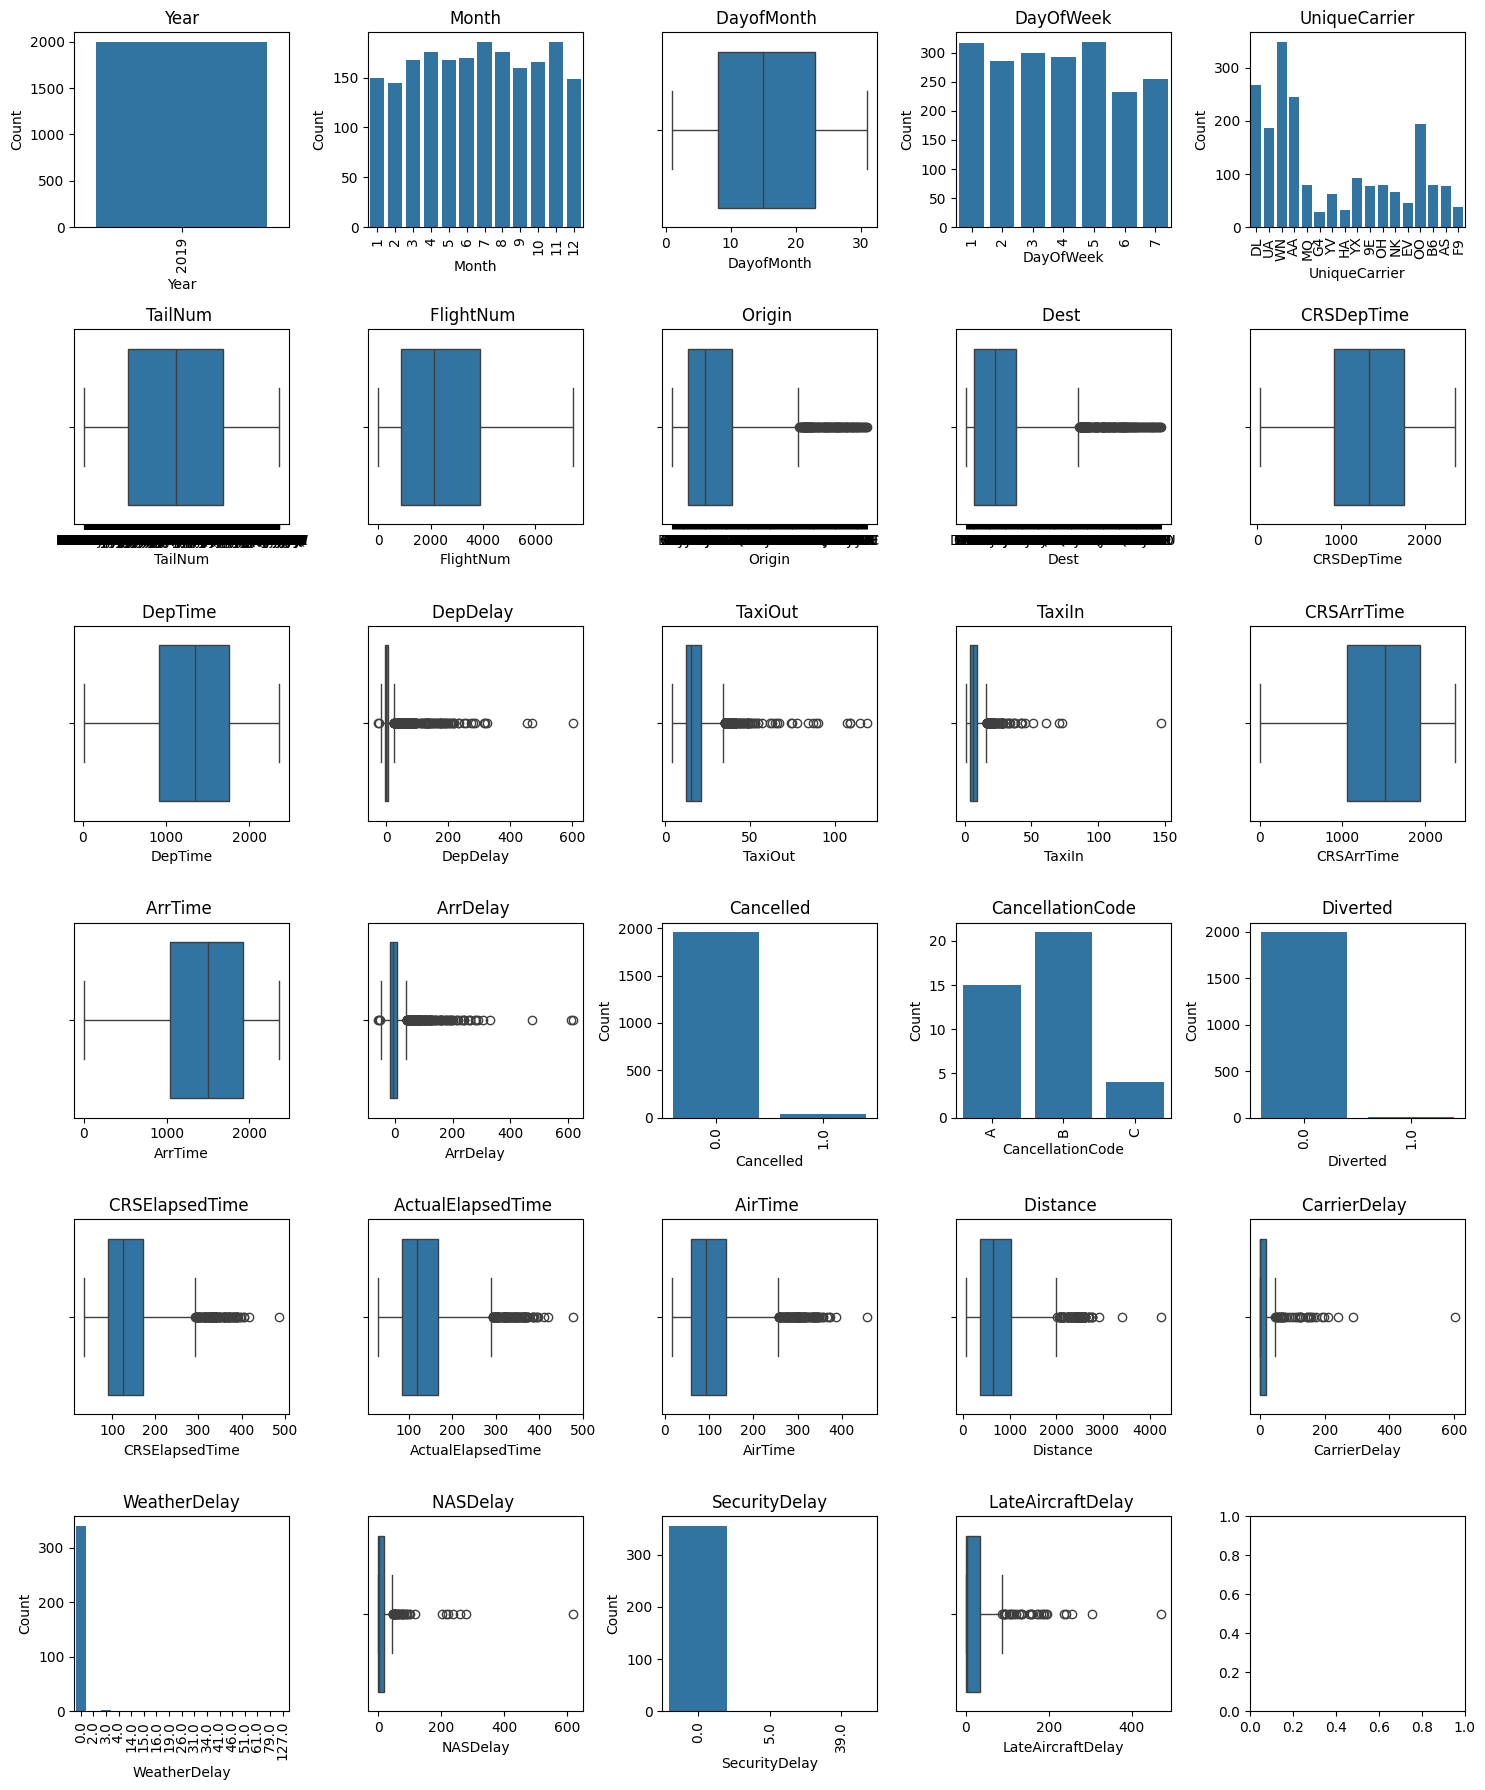

In [96]:
## 3.1 Visualize the value distribution of each column
## If the value type is continuous, we will use boxplot
## If the value type is discrete, we will use bar chart

import matplotlib.pyplot as plt
import seaborn as sns

threshold = 20
fig, axes = plt.subplots(6,5, figsize=(15,18))

axes = axes.flatten()

for i, col in enumerate(airline_samp.columns):
    ax = axes[i]
    distinct = airline_samp[col].nunique()

    if distinct <= threshold:
        sns.countplot(data=airline_samp, x=col, ax=ax)
        ax.set_title(f"{col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.tick_params(axis='x', rotation=90)
    else:
        sns.boxplot(x=airline_samp[col].dropna(), ax=ax)
        ax.set_title(f"{col} ")
        ax.set_xlabel(col)

plt.tight_layout()
plt.show()

In [97]:
## 3.2 Calculate the missing value percentage of each column

num_rows = airline_samp.shape[0]
missing_values = airline_samp.isnull().sum()
missing_percent = (missing_values/num_rows) * 100
print(missing_percent)

Year                  0.00
Month                 0.00
DayofMonth            0.00
DayOfWeek             0.00
UniqueCarrier         0.00
TailNum               0.45
FlightNum             0.00
Origin                0.00
Dest                  0.00
CRSDepTime            0.00
DepTime               1.80
DepDelay              1.80
TaxiOut               2.00
TaxiIn                2.10
CRSArrTime            0.00
ArrTime               2.10
ArrDelay              2.15
Cancelled             0.00
CancellationCode     98.00
Diverted              0.00
CRSElapsedTime        0.00
ActualElapsedTime     2.15
AirTime               2.15
Distance              0.00
CarrierDelay         82.10
WeatherDelay         82.10
NASDelay             82.10
SecurityDelay        82.10
LateAircraftDelay    82.10
dtype: float64


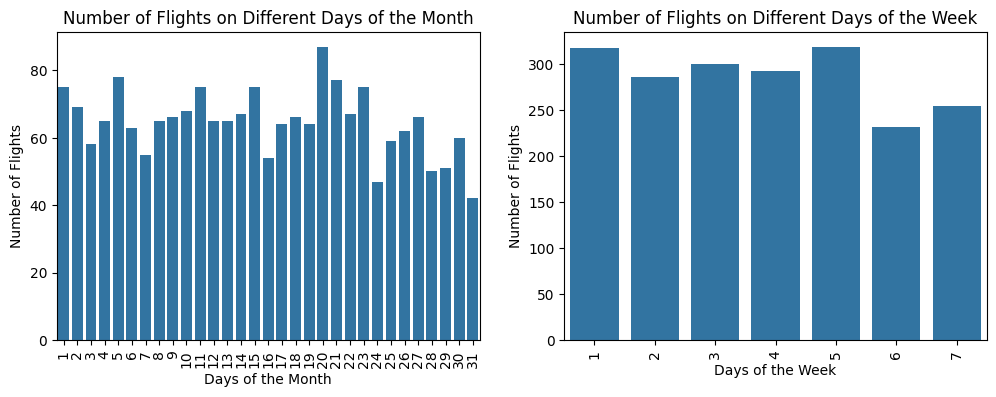

In [98]:
## 3.3 Count number of flights in different DayofMonth and DayOfWeek
day_month = {}
for day in airline_samp['DayofMonth']:
  if day in day_month:
    day_month[day] +=1
  else:
    day_month[day] = 1

day_week = {}
for day in airline_samp['DayOfWeek']:
  if day in day_week:
    day_week[day] +=1
  else:
    day_week[day] = 1

## Visualize with Barchart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=list(day_month.keys()), y=list(day_month.values()), ax = ax1)
ax1.set_title('Number of Flights on Different Days of the Month')
ax1.set_xlabel('Days of the Month')
ax1.set_ylabel('Number of Flights')
ax1.tick_params(axis='x', rotation=90)

sns.barplot(x=list(day_week.keys()), y=list(day_week.values()), ax = ax2)
ax2.set_title('Number of Flights on Different Days of the Week')
ax2.set_xlabel('Days of the Week')
ax2.set_ylabel('Number of Flights')
ax2.tick_params(axis='x', rotation=90)



Text(0.5, 0, 'Departure Time')

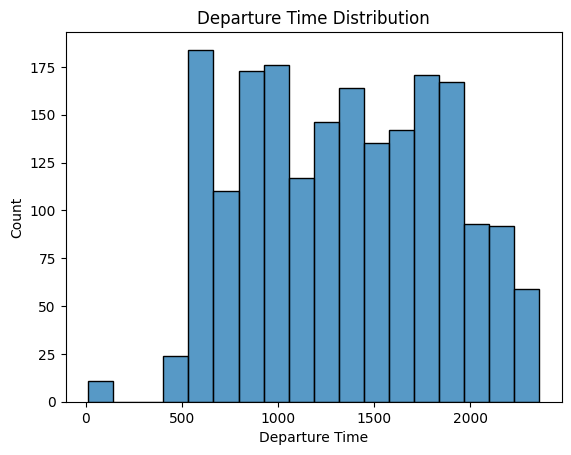

In [99]:
## 3.4.1 Histogram of Departure Time
sns.histplot(x='DepTime',data=airline_samp).set(title="Departure Time Distribution")
plt.xlabel('Departure Time')

Text(0.5, 0, 'Departure Delay')

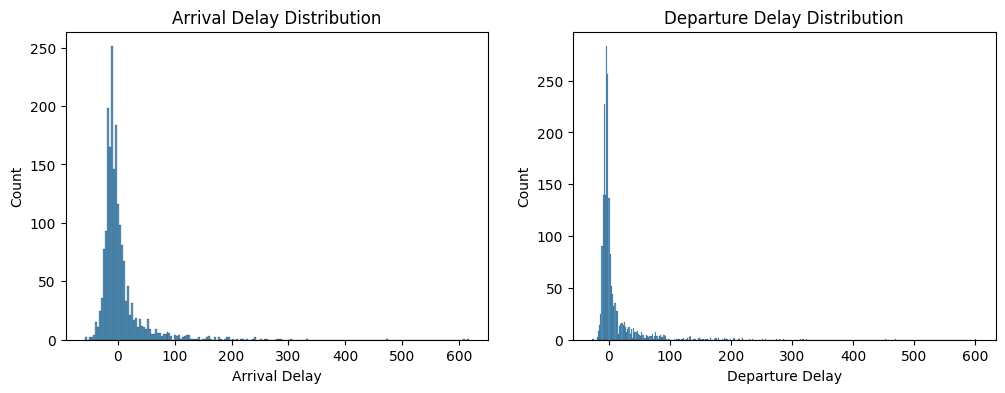

In [100]:
## 3.4.2 Histogram of arrival and departure delays
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(x='ArrDelay',data=airline_samp, ax= ax1).set(title="Arrival Delay Distribution")
ax1.set_xlabel('Arrival Delay')
sns.histplot(x='DepDelay',data=airline_samp, ax= ax2).set(title="Departure Delay Distribution")
ax2.set_xlabel('Departure Delay')

Text(0.5, 1.0, 'Arrival Delay vs Departure Time')

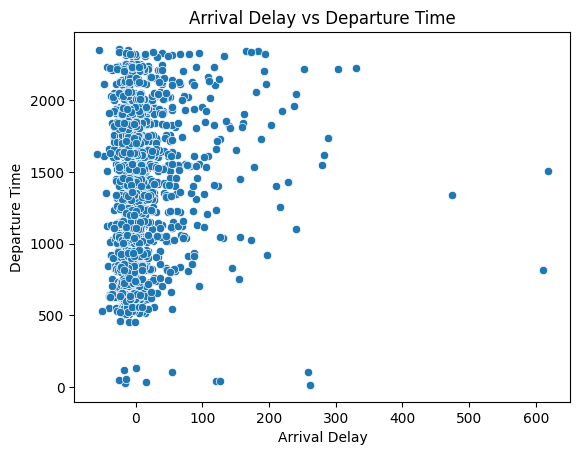

In [101]:
## 3.5.1 bivariate analysis: arrival delay vs departure time
# plot of arrival delay vs departure time Scatterplot

sns.scatterplot(data=airline_samp, x='ArrDelay', y='DepTime')
plt.xlabel("Arrival Delay")
plt.ylabel("Departure Time")
plt.title("Arrival Delay vs Departure Time")


Text(0.5, 1.0, 'Distance vs Airtime')

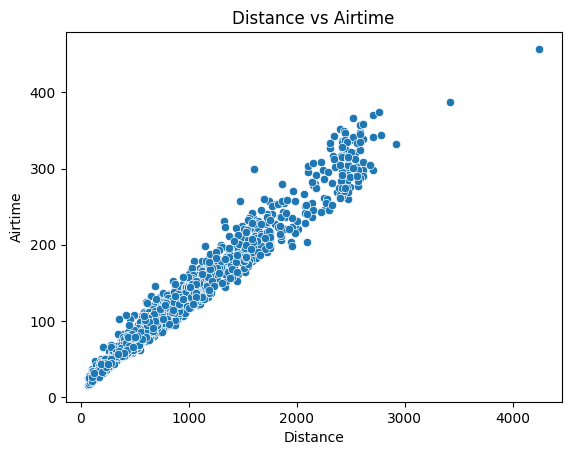

In [102]:
## 3.5.2 bivariate analysis: distance and airtimes
sns.scatterplot(data=airline_samp, x='Distance', y='AirTime')
plt.xlabel("Distance")
plt.ylabel("Airtime")
plt.title("Distance vs Airtime")

### 4. Feature engineering and cleaning

In [103]:
## 4.1 creating a categorical column for weekday

mapping = {     1: 'Monday',
                2: 'Tuesday',
                3: 'Wednesday',
                4: 'Thursday',
                5: 'Friday',
                6: 'Saturday',
                7: 'Sunday'}

airline_samp['Weekday'] = airline_samp['DayOfWeek'].map(mapping).astype('category')

In [104]:
## 4.2 first use a max(0,x) transform to get rid of negative values
## then create a new column using the log(1+x)
##'ArrDelay' and 'DepDelay'

airline_samp['ArrDelay'] = airline_samp['ArrDelay'].apply(lambda x: max(0, x))
airline_samp['ArrDelay_log'] = airline_samp['ArrDelay'].apply(lambda x: np.log1p(x))

airline_samp['DepDelay'] = airline_samp['DepDelay'].apply(lambda x: max(0, x))
airline_samp['DepDelay_log'] = airline_samp['DepDelay'].apply(lambda x: np.log1p(x))


In [105]:
## 4.3 Create a new column called 'DecimalDepTime', which convert 'CRSDepTime' (HHMM format) into decimal house
## For example: 1330 --> 13.5; 9:45 --> 9.75

def to_decimal_time(x):
    hours = x // 100 # 1330 -> 13
    minutes = x % 100 # 30
    return hours + (minutes / 60) # 30/60 = .5 + 13 = 13.5

airline_samp['DecimalDepTime'] = airline_samp['CRSDepTime'].apply(to_decimal_time)

Text(0.5, 0, 'Speed in mph')

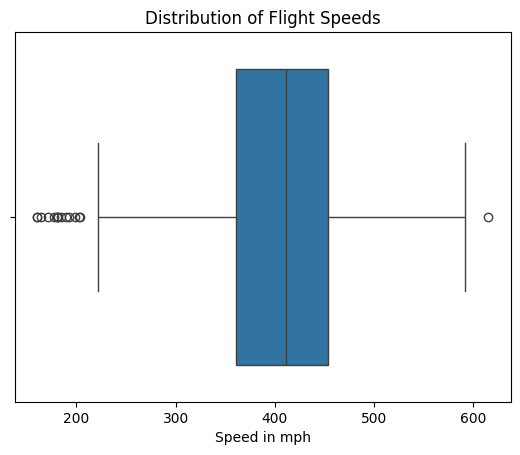

In [106]:
## 4.4 Create a new column 'speed', which is equal distance/AirTime. Make sure the unit of column is Miles Per Hour (mph)
airline_samp['speed'] = airline_samp['Distance'] / (airline_samp['AirTime'] / 60)


## boxplots of average speeds
# NOTE: not sure what average refers to here
sns.boxplot(x=airline_samp['speed'].dropna())
plt.title('Distribution of Flight Speeds')
plt.xlabel('Speed in mph')

In [107]:
#### 4.5 Filter flights with speeds greater than 650 mph and calculate their proportion in the dataset.
# sanity check: print(airline_samp['speed'].describe())

filter= airline_samp['speed'] > 650
fast_flights = airline_samp[filter]
proportion = len(fast_flights) / len(airline_samp)
print(proportion)

0.0


### 5. Save transformed data
This corresponds to the "Load" part in ETL

Regarding the saved file format
- raw CSV is good for sharing
- Parquet is better for analytics workflows

You can choose whatever format you like to save the transformed data in this exercise.

In [108]:
## Save transformed data
airline_samp.to_csv('airline_transformed.csv', index=False)